# LoRA 交互教学

配套 lecture：[`../lectures/01-lora.md`](../lectures/01-lora.md)  
配套论文：[`../papers/01-lora-2021.pdf`](../papers/01-lora-2021.pdf)

本 notebook 演示：
1. 环境检查
2. 手写 minimal LoRA
3. peft 调包 LoRA
4. **强一致性验证**（logits bit 精确）
5. rsLoRA 附录：scaling = α/√r 演示
6. LoRA+ 附录：A、B 不同学习率 demo
7. **mini training**：rsLoRA vs LoRA、LoRA+ vs LoRA 的 loss 曲线
8. 思考题

In [1]:
import sys
from pathlib import Path
import torch
import transformers
import peft
print(f'Python: {sys.version.split()[0]}')
print(f'torch:        {torch.__version__}')
print(f'CUDA built:   {torch.version.cuda}')
print(f'GPU avail:    {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:          {torch.cuda.get_device_name(0)}')
print(f'transformers: {transformers.__version__}')
print(f'peft:         {peft.__version__}')

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.13.13
torch:        2.13.0.dev20260602+cu130
CUDA built:   13.0
GPU avail:    True
GPU:          NVIDIA GeForce RTX 5090 Laptop GPU
transformers: 5.9.0
peft:         0.19.1


## 2. 手写 minimal LoRA

公式 (1): $h = W_0 x + \frac{\alpha}{r} BA x$，每层 c_attn 加 LoRA。

In [2]:
src_dir = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src_dir))

from lora_minimal import LoRAGPT2, LoRALinear
from common import print_param_summary

torch.manual_seed(42)
model = LoRAGPT2(r=8, alpha=16)
print_param_summary(model, 'LoRAGPT2 (r=8, target=c_attn)')

# 取第一层 LoRA 看 shape
for name, mod in model.named_modules():
    if isinstance(mod, LoRALinear):
        print(f'\n第一层 LoRA: {name}')
        print(f'  A shape: {tuple(mod.A.shape)} = (r=8, d_in=768)')
        print(f'  B shape: {tuple(mod.B.shape)} = (d_out=2304, r=8)')
        print(f'  scaling = α/r = {mod.scaling}')
        break

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17441.89it/s]

  LoRAGPT2 (r=8, target=c_attn)
  Total params:      124,734,720
  Trainable params:      294,912  (0.2364%)
  Frozen params:     124,439,808

第一层 LoRA: lm.transformer.h.0.attn.c_attn
  A shape: (8, 768) = (r=8, d_in=768)
  B shape: (2304, 8) = (d_out=2304, r=8)
  scaling = α/r = 2.0


## 3. peft 调包 LoRA

In [3]:
from lora_peft import build_peft_model

torch.manual_seed(42)
peft_model = build_peft_model(r=8, alpha=16)
print_param_summary(peft_model, 'peft LoRA (r=8)')

print('\npeft 内部 layer 0 参数：')
for name, p in peft_model.named_parameters():
    if 'h.0.attn.c_attn.lora' in name:
        print(f'  {name}: shape={tuple(p.shape)}')
print('\n→ 参数布局与 minimal 完全一致')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17156.04it/s]

W0603 15:35:58.888000 12816 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


  peft LoRA (r=8)
  Total params:      124,734,720
  Trainable params:      294,912  (0.2364%)
  Frozen params:     124,439,808

peft 内部 layer 0 参数：
  base_model.model.transformer.h.0.attn.c_attn.lora_A.default.weight: shape=(8, 768)
  base_model.model.transformer.h.0.attn.c_attn.lora_B.default.weight: shape=(2304, 8)

→ 参数布局与 minimal 完全一致


C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\peft\tuners\lora\layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 4. 强一致性验证

LoRA 无 reparam、无 LSTM、无随机 dropout，预期 logits **bit 精确一致**。

In [4]:
tests_dir = (Path.cwd().parent / 'src' / 'tests').resolve()
sys.path.insert(0, str(tests_dir))
from test_lora_consistency import test_logits_match
test_logits_match()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14763.41it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16225.12it/s]

peft 可训练参数（按层组织）：
  探测到 12 层 LoRA 参数
  layer 0 A shape: (8, 768)
  layer 0 B shape: (2304, 8)

复制 minimal A、B 到 peft 中...
  [OK] 12 层 LoRA 参数已对齐



minimal logits: (1, 2, 50257)
peft    logits: (1, 2, 50257)

logits 最大绝对误差: 0.0000e+00
logits 最大相对误差: 0.0000e+00
[PASS] minimal 与 peft 输出强一致


## 5. rsLoRA 附录：scaling = α/√r

对比不同 r 下，LoRA 与 rsLoRA 的 scaling 数值。

In [5]:
import math

print(f'{"r":>6} {"LoRA α/r":>12} {"rsLoRA α/√r":>16}')
print(f'{"-"*6} {"-"*12} {"-"*16}')
for r in [4, 8, 16, 64, 256, 1024]:
    lora_s = 16 / r
    rs_s = 16 / math.sqrt(r)
    print(f'{r:>6} {lora_s:>12.5f} {rs_s:>16.5f}')
print('\n→ r 越大，LoRA 的 scaling 衰减越快，rsLoRA 保持 |ΔW| 量级稳定')

     r     LoRA α/r      rsLoRA α/√r
------ ------------ ----------------
     4      4.00000          8.00000
     8      2.00000          5.65685
    16      1.00000          4.00000
    64      0.25000          2.00000
   256      0.06250          1.00000
  1024      0.01562          0.50000

→ r 越大，LoRA 的 scaling 衰减越快，rsLoRA 保持 |ΔW| 量级稳定


## 6. LoRA+ 附录：A、B 不同学习率

In [6]:
from lora_extensions import lora_plus_param_groups

torch.manual_seed(42)
model = LoRAGPT2(r=8, alpha=16)
groups = lora_plus_param_groups(model, lr_A=1e-4, lambda_B=16.0)
for g in groups:
    n = sum(p.numel() for p in g['params'])
    print(f"  group {g['_name']:<10}: {n:>10,} params, lr = {g['lr']:.1e}")
print('\n→ B 的学习率比 A 快 16×，加速早期收敛')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17895.96it/s]

  group lora_A    :     73,728 params, lr = 1.0e-04
  group lora_B    :    221,184 params, lr = 1.6e-03

→ B 的学习率比 A 快 16×，加速早期收敛


## 7. Mini training：rsLoRA vs LoRA 在 r=64 上的收敛

rsLoRA 论文的主要 claim：大 r 下，LoRA 退化、rsLoRA 仍能正常训练。

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15946.29it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15622.03it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


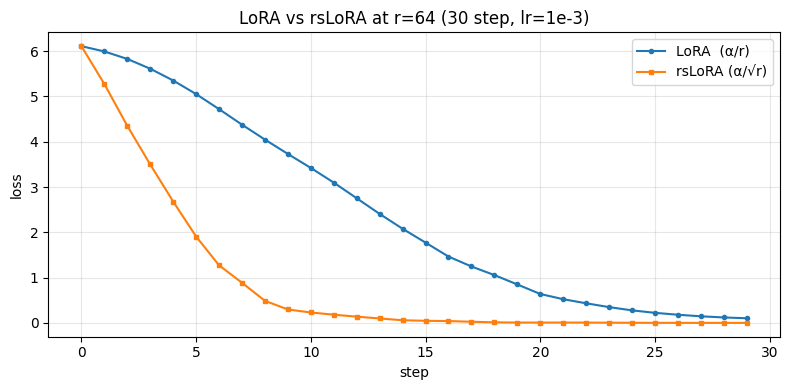

LoRA   final loss: 0.1042
rsLoRA final loss: 0.0022
→ rsLoRA 在大 r 下确实更快收敛


In [7]:
import matplotlib.pyplot as plt
from lora_extensions import RSLoRAGPT2

torch.manual_seed(42)
lora = LoRAGPT2(r=64, alpha=16)
torch.manual_seed(42)
rslora = RSLoRAGPT2(r=64, alpha=16)

tok = lora.tokenizer
inputs = tok([
    'hello world this is a test',
    'i love this amazing product',
    'absolutely terrible do not buy',
    'the movie was fantastic and beautiful',
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

opt_l = torch.optim.AdamW([p for p in lora.parameters() if p.requires_grad], lr=1e-3)
opt_r = torch.optim.AdamW([p for p in rslora.parameters() if p.requires_grad], lr=1e-3)

loss_l, loss_r = [], []
for step in range(30):
    for m, opt, losses in [(lora, opt_l, loss_l), (rslora, opt_r, loss_r)]:
        opt.zero_grad()
        out = m(**inputs)
        out.loss.backward()
        opt.step()
        losses.append(out.loss.item())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_l, label='LoRA  (α/r)', marker='o', markersize=3)
ax.plot(loss_r, label='rsLoRA (α/√r)', marker='s', markersize=3)
ax.set_xlabel('step')
ax.set_ylabel('loss')
ax.set_title('LoRA vs rsLoRA at r=64 (30 step, lr=1e-3)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'LoRA   final loss: {loss_l[-1]:.4f}')
print(f'rsLoRA final loss: {loss_r[-1]:.4f}')
print(f'→ rsLoRA 在大 r 下确实更快收敛')

## 8. Mini training：LoRA+ vs LoRA 的早期收敛

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17308.64it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15718.55it/s]

C:\Users\ericp\AppData\Local\Temp\ipykernel_12816\3434327659.py:30: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_12816\3434327659.py:30: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32479 (\N{CJK UNIFIED IDEOGRAPH-7EDF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


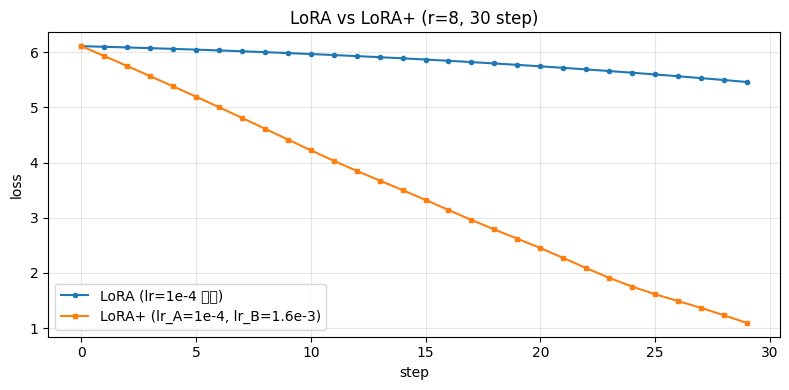

LoRA   final loss: 5.4589
LoRA+  final loss: 1.0963
→ LoRA+ 早期收敛更快（B 的学习率更大）


In [8]:
torch.manual_seed(42)
lora_baseline = LoRAGPT2(r=8, alpha=16)
torch.manual_seed(42)
lora_plus = LoRAGPT2(r=8, alpha=16)

opt_base = torch.optim.AdamW(
    [p for p in lora_baseline.parameters() if p.requires_grad], lr=1e-4
)
opt_plus = torch.optim.AdamW(
    lora_plus_param_groups(lora_plus, lr_A=1e-4, lambda_B=16.0)
)

loss_base, loss_plus = [], []
for step in range(30):
    for m, opt, losses in [(lora_baseline, opt_base, loss_base), (lora_plus, opt_plus, loss_plus)]:
        opt.zero_grad()
        out = m(**inputs)
        out.loss.backward()
        opt.step()
        losses.append(out.loss.item())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_base, label='LoRA (lr=1e-4 统一)', marker='o', markersize=3)
ax.plot(loss_plus, label='LoRA+ (lr_A=1e-4, lr_B=1.6e-3)', marker='s', markersize=3)
ax.set_xlabel('step')
ax.set_ylabel('loss')
ax.set_title('LoRA vs LoRA+ (r=8, 30 step)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'LoRA   final loss: {loss_base[-1]:.4f}')
print(f'LoRA+  final loss: {loss_plus[-1]:.4f}')
print('→ LoRA+ 早期收敛更快（B 的学习率更大）')

## 9. 思考题

**主篇思考题**：

1. **公式题**：如果 B 也用 Gaussian 初始化（非零），第 1 步训练后 ΔW 会是什么？为什么破坏 LoRA 设计？
2. **公式题**：推导 ∂L/∂A 和 ∂L/∂B。论文 §4.1 提到 A、B 梯度量级不对称，从你的推导能看出原因吗？
3. **代码题**：测试 `model.merge_all()` 后参数量是否变化（应该 trainable 仍是 ~30 万但形式上 LoRA 已合并）。
4. **设计题**：LoRA 为什么只打 W_q + W_v 而不是 FFN？
5. **对比题**：在 prompt-tuning-family 中，Prompt Tuning 用 7.7K 参数，LoRA 用 0.44M。前者参数少 60×，为什么没'大杀四方'？
6. **实践题**：把 `r` 从 8 改成 64、256，观察 LoRA 与 rsLoRA 的对比变化。

**附录思考题**：

7. **rsLoRA**：推导 ||BA||_F 关于 r 的尺度依赖（假设 A ~ N(0, σ²), B 零初始化后训练 T 步）。
8. **LoRA+**：为什么 λ > 64 会训练不稳？